# 09. Reconstruction-Based Detection: PCA and Autoencoders

The previous notebooks studied detectors that score unusual observations using distance, density, trees, support boundaries, and local geometry. This notebook studies another major family of anomaly detectors: **reconstruction-based detection**.

The idea is simple and powerful. Learn how normal cases can be compressed and reconstructed. Cases that cannot be reconstructed well are suspicious because they do not follow the regular relationships learned from normal data.

This gives us two closely related tools:

1. **PCA reconstruction:** a linear baseline that reconstructs observations from a low-dimensional subspace.
2. **Autoencoder reconstruction:** a nonlinear neural-network-style baseline that reconstructs observations through a bottleneck representation.

The decision-science question asks whether the reconstruction score creates a reliable review workflow: which failures are caught, which legitimate regimes are over-alerted, and which anomalies are missed because they are easy to reconstruct.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain reconstruction-based anomaly detection as normal-pattern compression followed by residual scoring.
2. Derive PCA reconstruction error from projection onto a low-dimensional subspace.
3. Explain the autoencoder objective and the role of a bottleneck representation.
4. Compare reconstruction thresholds with fixed review budgets.
5. Diagnose when PCA residuals and autoencoder residuals agree or disagree.
6. Identify failure modes: overcomplete reconstruction, legitimate new regimes, residual spillover, and reconstructable anomalies.
7. Translate reconstruction scores into an operational monitoring recommendation.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 8
pd.set_option('display.max_columns', 80)

RANDOM_SEED = 50909
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'normal': '#9eb3c2',
    'new_regime': '#f59e0b',
    'anomaly': '#dc2626',
    'pca': '#2563eb',
    'ae': '#059669',
    'threshold': '#111827',
    'review': '#7c3aed',
    'selected': '#f97316',
}


## 1. Reconstruction as a Normality Score

Let $x_i$ be an observation with $p$ measured variables. A reconstruction model learns a function

$$
r(x) \approx x
$$

for observations that look like normal training data. The anomaly score is a reconstruction loss, commonly

$$
s(x) = \sum_{j=1}^{p} (x_j - r_j(x))^2.
$$

If the model is trained only on normal behavior, then large reconstruction error suggests that the observation violates normal relationships among variables.

This is a subtle idea. A high reconstruction error does not prove the observation is dangerous. It says the observation is poorly explained by the learned normal representation. A low reconstruction error does not prove safety either. A flexible model may reconstruct some abnormal cases well.


## 2. PCA Reconstruction Error

PCA gives the cleanest mathematical version of reconstruction detection.

Suppose $z$ is a standardized observation. PCA estimates orthonormal loading vectors. If $P_k$ contains the first $k$ principal loading vectors, the rank-$k$ reconstruction is

$$
\hat{z} = P_k P_k^T z.
$$

The PCA residual score is

$$
Q(z) = \sum_{j=1}^{p} (z_j - \hat{z}_j)^2.
$$

In statistical process monitoring, this is often called the squared prediction error or $Q$ statistic. It measures how far the observation lies from the retained PCA subspace. PCA can also monitor distance inside the retained subspace using Hotelling-type scores, but this notebook focuses on reconstruction residuals because they connect directly to autoencoders.


## 3. Autoencoder Reconstruction Error

An autoencoder replaces the linear PCA projection with a learned encoder-decoder pair.

The encoder maps the input into a lower-dimensional latent representation:

$$
h = g(x).
$$

The decoder maps the latent representation back to the original feature space:

$$
\hat{x} = f(h).
$$

The model is trained by minimizing reconstruction loss on baseline data:

$$
\min \frac{1}{n}\sum_{i=1}^n \sum_{j=1}^{p} (x_{ij} - \hat{x}_{ij})^2.
$$

The bottleneck matters. If the model is too expressive, it may learn an almost-identity map and reconstruct anomalies well. If the model is too restrictive, it may over-alert normal variation. The architecture is therefore part of the decision system as well as a modeling detail.


## 4. How Reconstruction Detectors Behave

| Detector | Representation | Strength | Common failure mode |
|---|---|---|---|
| PCA residual | Linear low-dimensional subspace | Transparent baseline for correlated tabular sensors | Misses nonlinear normal structure or abnormal points inside the subspace |
| Autoencoder residual | Nonlinear bottleneck representation | Can learn curved normal manifolds | May reconstruct anomalies if too flexible or poorly regularized |
| Fixed residual threshold | Score cutoff calibrated on normal validation data | Stable alert rule when labels are scarce | Alert rate drifts when normal behavior shifts |
| Top review queue | Highest scores under a capacity constraint | Aligns with analyst bandwidth | Recall is capped by the queue size |

A reconstruction detector is usually best treated as a **screening system**. It prioritizes cases for review, root-cause analysis, maintenance checks, or follow-up experiments. It should be paired with calibration, segment monitoring, and human review.


## 5. Synthetic Case: Manufacturing Line Monitoring

Imagine a manufacturing analytics team monitoring a high-throughput packaging line. The team has a large baseline of sensor telemetry from normal production. They want to identify future line states that may indicate equipment wear, sensor bias, recipe mismatch, control-loop oscillation, or subtle quality drift.

The system also faces a realistic operational complication: a legitimate new product grade appears in future data. It is not a fault, but it is partly outside the historical baseline. This lets us inspect false alerts caused by normal-regime expansion.

The target workflow is:

1. Train reconstruction models on normal baseline data.
2. Calibrate residual thresholds on held-out normal validation data.
3. Score future observations.
4. Compare model-boundary alerts with a fixed top-5% review queue.
5. Inspect segment coverage and feature residuals before recommending deployment.


In [2]:
# Section focus: 5. Synthetic Case: Manufacturing Line Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

FEATURE_COLS = [
    'line_speed',
    'throughput',
    'motor_current',
    'vibration_rms',
    'bearing_temp_c',
    'hydraulic_pressure',
    'flow_rate',
    'cycle_time_sec',
    'energy_kwh',
    'defect_proxy',
    'rework_minutes',
    'sensor_noise_index',
]


def normal_block(n, regime, rng):
    """Carry out the normal block step used in the 09. Reconstruction-Based Detection: PCA and Autoencoders workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    regime : object
        The regime setting that controls the normal block calculation in this notebook.
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the normal block calculation and reused by later cells.
    """
    params = {
        'normal_steady': (0.0, 0.0, 0.0),
        'normal_peak_load': (0.65, 0.8, 0.15),
        'new_product_grade': (1.25, 1.35, 0.35),
    }
    speed_mu, load_mu, ambient_mu = params[regime]
    speed = rng.normal(speed_mu, 0.75, n)
    load = rng.normal(load_mu, 0.70, n)
    ambient = rng.normal(ambient_mu, 0.65, n)

    line_speed = np.clip(58 + 7.0 * speed - 1.2 * load + rng.normal(0, 1.8, n), 30, 95)
    throughput = np.clip(420 + 36 * speed - 10 * load + rng.normal(0, 12, n), 250, 620)
    motor_current = np.clip(44 + 5.5 * load + 1.3 * speed + 0.8 * load**2 + rng.normal(0, 1.8, n), 25, 85)
    vibration_rms = np.clip(0.18 + 0.055 * load + 0.015 * speed + 0.018 * load**2 + rng.normal(0, 0.025, n), 0.04, 0.90)
    bearing_temp_c = np.clip(68 + 3.5 * load + 1.5 * ambient + 12 * vibration_rms + rng.normal(0, 1.8, n), 45, 115)
    hydraulic_pressure = np.clip(36 + 2.8 * load - 1.1 * speed + rng.normal(0, 1.6, n), 20, 65)
    flow_rate = np.clip(115 + 7.0 * speed - 2.5 * load + rng.normal(0, 4.0, n), 75, 170)
    cycle_time_sec = np.clip(52 - 3.0 * speed + 2.8 * load + 0.7 * load**2 + rng.normal(0, 1.8, n), 30, 90)
    energy_kwh = np.clip(8 + 0.09 * motor_current + 0.012 * line_speed + 0.55 * np.maximum(load, 0)**2 + rng.normal(0, 0.45, n), 5, 22)
    defect_proxy = np.clip(1.3 + 2.2 * vibration_rms + 0.025 * bearing_temp_c + 0.35 * np.maximum(load, 0) + rng.normal(0, 0.55, n), 0, 9)
    rework_minutes = np.clip(3.2 + 0.75 * defect_proxy + 0.75 * np.maximum(load, 0) + rng.normal(0, 1.1, n), 0, 18)
    sensor_noise_index = np.clip(1.8 + 0.35 * np.abs(ambient) + 0.22 * np.maximum(load, 0) + rng.normal(0, 0.35, n), 0, 8)

    out = pd.DataFrame({
        'line_speed': line_speed,
        'throughput': throughput,
        'motor_current': motor_current,
        'vibration_rms': vibration_rms,
        'bearing_temp_c': bearing_temp_c,
        'hydraulic_pressure': hydraulic_pressure,
        'flow_rate': flow_rate,
        'cycle_time_sec': cycle_time_sec,
        'energy_kwh': energy_kwh,
        'defect_proxy': defect_proxy,
        'rework_minutes': rework_minutes,
        'sensor_noise_index': sensor_noise_index,
        'regime': regime,
        'known_anomaly': 0,
    })
    return out


def anomaly_block(n, anomaly_type, rng):
    """Carry out the anomaly block step used in the 09. Reconstruction-Based Detection: PCA and Autoencoders workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    anomaly_type : object
        The anomaly type setting that controls the anomaly block calculation in this notebook.
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the anomaly block calculation and reused by later cells.
    """
    base_regime = 'normal_peak_load' if anomaly_type in ['bearing_wear', 'control_loop_oscillation'] else 'normal_steady'
    out = normal_block(n, base_regime, rng).copy()
    out['regime'] = anomaly_type
    out['known_anomaly'] = 1

    if anomaly_type == 'bearing_wear':
        out['vibration_rms'] = np.clip(out['vibration_rms'] * rng.normal(2.2, 0.18, n) + rng.normal(0.10, 0.03, n), 0, 1.6)
        out['bearing_temp_c'] = np.clip(out['bearing_temp_c'] + rng.normal(13, 3, n), 45, 135)
        out['motor_current'] = np.clip(out['motor_current'] + rng.normal(6.5, 1.5, n), 25, 100)
        out['energy_kwh'] = np.clip(out['energy_kwh'] + rng.normal(2.0, 0.5, n), 5, 28)
        out['defect_proxy'] = np.clip(out['defect_proxy'] + rng.normal(2.5, 0.7, n), 0, 14)
        out['rework_minutes'] = np.clip(out['rework_minutes'] + rng.normal(3.5, 1.0, n), 0, 25)
    elif anomaly_type == 'sensor_bias':
        out['hydraulic_pressure'] = np.clip(out['hydraulic_pressure'] + rng.normal(10, 2.0, n), 20, 80)
        out['flow_rate'] = np.clip(out['flow_rate'] - rng.normal(10, 2.5, n), 65, 170)
        out['sensor_noise_index'] = np.clip(out['sensor_noise_index'] + rng.normal(2.0, 0.5, n), 0, 10)
    elif anomaly_type == 'recipe_mismatch':
        out['line_speed'] = np.clip(out['line_speed'] + rng.normal(11, 3, n), 30, 105)
        out['flow_rate'] = np.clip(out['flow_rate'] - rng.normal(18, 4, n), 55, 170)
        out['cycle_time_sec'] = np.clip(out['cycle_time_sec'] + rng.normal(8, 2.5, n), 30, 100)
        out['defect_proxy'] = np.clip(out['defect_proxy'] + rng.normal(2.0, 0.7, n), 0, 14)
        out['rework_minutes'] = np.clip(out['rework_minutes'] + rng.normal(2.5, 1.0, n), 0, 25)
    elif anomaly_type == 'control_loop_oscillation':
        out['hydraulic_pressure'] = np.clip(out['hydraulic_pressure'] + rng.normal(0, 7.5, n), 15, 85)
        out['cycle_time_sec'] = np.clip(out['cycle_time_sec'] + rng.normal(8, 5, n), 25, 105)
        out['sensor_noise_index'] = np.clip(out['sensor_noise_index'] + rng.normal(3.0, 0.7, n), 0, 11)
        out['vibration_rms'] = np.clip(out['vibration_rms'] + rng.normal(0.16, 0.05, n), 0, 1.2)
    elif anomaly_type == 'stealth_quality_drift':
        out['defect_proxy'] = np.clip(out['defect_proxy'] + rng.normal(1.35, 0.45, n), 0, 12)
        out['rework_minutes'] = np.clip(out['rework_minutes'] + rng.normal(1.8, 0.8, n), 0, 22)
        out['energy_kwh'] = np.clip(out['energy_kwh'] + rng.normal(0.45, 0.25, n), 5, 24)
    return out


def simulate_line_monitoring(seed=RANDOM_SEED):
    """Create a simulated line monitoring data set for the 09. Reconstruction-Based Detection: PCA and Autoencoders case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    train = pd.concat([
        normal_block(1900, 'normal_steady', rng),
        normal_block(700, 'normal_peak_load', rng),
    ], ignore_index=True)
    validation = pd.concat([
        normal_block(520, 'normal_steady', rng),
        normal_block(230, 'normal_peak_load', rng),
    ], ignore_index=True)
    future = pd.concat([
        normal_block(1150, 'normal_steady', rng),
        normal_block(530, 'normal_peak_load', rng),
        normal_block(260, 'new_product_grade', rng),
        anomaly_block(95, 'bearing_wear', rng),
        anomaly_block(80, 'sensor_bias', rng),
        anomaly_block(80, 'recipe_mismatch', rng),
        anomaly_block(75, 'control_loop_oscillation', rng),
        anomaly_block(80, 'stealth_quality_drift', rng),
    ], ignore_index=True)
    future = future.sample(frac=1, random_state=seed).reset_index(drop=True)
    return train, validation, future


train_df, validation_df, future_df = simulate_line_monitoring()

summary = pd.DataFrame({
    'split': ['training', 'validation', 'future'],
    'rows': [len(train_df), len(validation_df), len(future_df)],
    'known_anomaly_rate': [train_df['known_anomaly'].mean(), validation_df['known_anomaly'].mean(), future_df['known_anomaly'].mean()],
    'number_of_regimes': [train_df['regime'].nunique(), validation_df['regime'].nunique(), future_df['regime'].nunique()],
})

smart_display(summary.style.format({'known_anomaly_rate': '{:.1%}'}))
smart_display(future_df['regime'].value_counts().rename_axis('regime').reset_index(name='future_rows'))


,split,rows,known_anomaly_rate,number_of_regimes
0,training,2600,0.0%,2
1,validation,750,0.0%,2
2,future,2350,17.4%,8


,regime,future_rows
0,normal_steady,1150
1,normal_peak_load,530
2,new_product_grade,260
3,bearing_wear,95
4,sensor_bias,80
5,recipe_mismatch,80
6,stealth_quality_drift,80
7,control_loop_oscillation,75


The training and validation sets contain only historical normal regimes. The future set contains normal regimes, a legitimate new product grade, and several known synthetic anomaly types.

This setup mirrors a common production problem. The model is trained with mostly normal data because confirmed failure labels are sparse or delayed. We still simulate future labels here so we can evaluate what the detector would do.


## 6. Fit PCA and Autoencoder Reconstruction Models

We standardize all features using the normal training baseline. This is essential because reconstruction error is scale-sensitive. Without standardization, a high-variance variable can dominate the residual score.

For PCA, we retain enough components to explain about 90% of the training variance. For the autoencoder, we use a small bottleneck hidden layer. In a production deep-learning stack this could be implemented with PyTorch or TensorFlow; here we use `MLPRegressor` so the lecture remains lightweight and reproducible.


In [3]:
# Section focus: 6. Fit PCA and Autoencoder Reconstruction Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLS])
X_validation = scaler.transform(validation_df[FEATURE_COLS])
X_future = scaler.transform(future_df[FEATURE_COLS])

pca = PCA(n_components=0.90, random_state=RANDOM_SEED)
pca.fit(X_train)


def pca_reconstruct(X):
    """Carry out the pca reconstruct step used in the 09. Reconstruction-Based Detection: PCA and Autoencoders workflow.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    
    Returns
    -------
    object
        Intermediate result produced by the pca reconstruct calculation and reused by later cells.
    """
    return pca.inverse_transform(pca.transform(X))


def reconstruction_score(X, X_hat):
    """Carry out the reconstruction score step used in the 09. Reconstruction-Based Detection: PCA and Autoencoders workflow.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    X_hat : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the reconstruction score calculation.
    """
    return np.mean((X - X_hat) ** 2, axis=1)

train_pca_score = reconstruction_score(X_train, pca_reconstruct(X_train))
validation_pca_score = reconstruction_score(X_validation, pca_reconstruct(X_validation))
future_pca_score = reconstruction_score(X_future, pca_reconstruct(X_future))

autoencoder = MLPRegressor(
    hidden_layer_sizes=(8, 3, 8),
    activation='tanh',
    solver='lbfgs',
    alpha=0.001,
    max_iter=900,
    max_fun=20000,
    random_state=RANDOM_SEED,
)
autoencoder.fit(X_train, X_train)

train_ae_score = reconstruction_score(X_train, autoencoder.predict(X_train))
validation_ae_score = reconstruction_score(X_validation, autoencoder.predict(X_validation))
future_ae_score = reconstruction_score(X_future, autoencoder.predict(X_future))

pca_threshold = np.quantile(validation_pca_score, 0.95)
ae_threshold = np.quantile(validation_ae_score, 0.95)

future_df = future_df.copy()
future_df['pca_score'] = future_pca_score
future_df['ae_score'] = future_ae_score
future_df['pca_boundary_alert'] = future_df['pca_score'] >= pca_threshold
future_df['ae_boundary_alert'] = future_df['ae_score'] >= ae_threshold
future_df['status'] = np.select(
    [future_df['known_anomaly'].eq(1), future_df['regime'].eq('new_product_grade')],
    ['Known anomaly', 'Legitimate new regime'],
    default='Known normal',
)

model_setup = pd.DataFrame([
    {
        'model': 'PCA residual',
        'representation': f'{pca.n_components_} linear components',
        'validation_threshold': pca_threshold,
        'training_mean_score': train_pca_score.mean(),
        'validation_mean_score': validation_pca_score.mean(),
    },
    {
        'model': 'Bottleneck autoencoder',
        'representation': '12 -> 8 -> 3 -> 8 -> 12 nonlinear map',
        'validation_threshold': ae_threshold,
        'training_mean_score': train_ae_score.mean(),
        'validation_mean_score': validation_ae_score.mean(),
    },
])

smart_display(model_setup.style.format({
    'validation_threshold': '{:.4f}',
    'training_mean_score': '{:.4f}',
    'validation_mean_score': '{:.4f}',
}))


,model,representation,validation_threshold,training_mean_score,validation_mean_score
0,PCA residual,6 linear components,0.2209,0.0977,0.1022
1,Bottleneck autoencoder,12 -> 8 -> 3 -> 8 -> 12 nonlinear map,0.5013,0.2372,0.2359


The PCA detector is intentionally interpretable: it keeps a small number of principal components and treats residual distance from that linear subspace as the anomaly score.

The autoencoder uses a nonlinear bottleneck. Its score is still a reconstruction error, but the reconstruction map is no longer restricted to a linear projection. This can help when normal operations follow curved relationships. It also increases governance burden because architecture, regularization, and training stability affect what gets reconstructed.


## 7. PCA Residuals and the Normal Subspace

A useful first diagnostic is the PCA variance curve. If a few components explain most normal variation, reconstruction detection has a plausible low-dimensional structure to learn.

We then inspect score distributions. A good screening score should put many known anomalies in the right tail while keeping ordinary normal observations mostly below the validation-calibrated threshold.


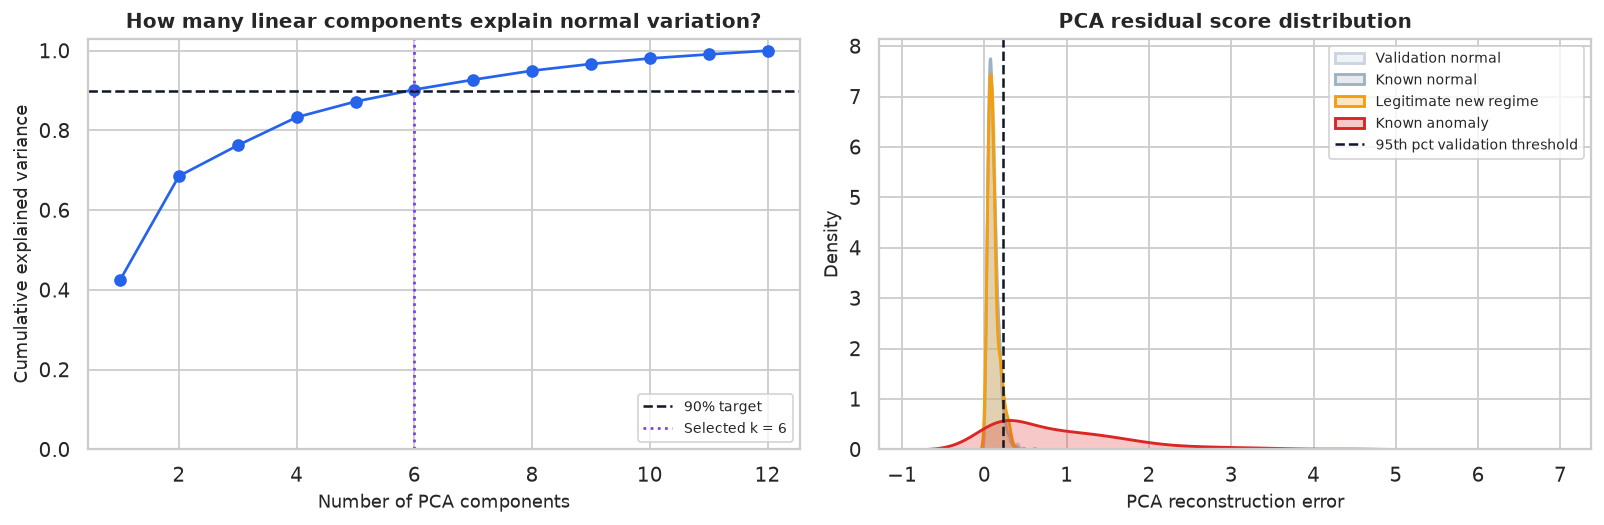

In [4]:
# Section focus: 7. PCA Residuals and the Normal Subspace.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

explained = np.cumsum(pca.explained_variance_ratio_)
all_pca = PCA(n_components=len(FEATURE_COLS), random_state=RANDOM_SEED).fit(X_train)
full_explained = np.cumsum(all_pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(np.arange(1, len(full_explained) + 1), full_explained, marker='o', color=PALETTE['pca'])
axes[0].axhline(0.90, color=PALETTE['threshold'], linestyle='--', linewidth=1.4, label='90% target')
axes[0].axvline(pca.n_components_, color=PALETTE['review'], linestyle=':', linewidth=1.5, label=f'Selected k = {pca.n_components_}')
axes[0].set_ylim(0, 1.03)
axes[0].set_xlabel('Number of PCA components')
axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('How many linear components explain normal variation?')
axes[0].legend(loc='lower right')

score_plot = pd.DataFrame({
    'score': np.r_[validation_pca_score, future_df['pca_score'].to_numpy()],
    'group': np.r_[np.repeat('Validation normal', len(validation_pca_score)), future_df['status'].to_numpy()],
})
order = ['Validation normal', 'Known normal', 'Legitimate new regime', 'Known anomaly']
colors = {
    'Validation normal': '#cbd5e1',
    'Known normal': PALETTE['normal'],
    'Legitimate new regime': PALETTE['new_regime'],
    'Known anomaly': PALETTE['anomaly'],
}
for group in order:
    subset = score_plot[score_plot['group'] == group]
    sns.kdeplot(data=subset, x='score', ax=axes[1], fill=True, alpha=0.25, linewidth=1.6, color=colors[group], label=group)
axes[1].axvline(pca_threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.4, label='95th pct validation threshold')
axes[1].set_xlabel('PCA reconstruction error')
axes[1].set_ylabel('Density')
axes[1].set_title('PCA residual score distribution')
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


The PCA variance curve tells us how much normal variation is being represented by the retained subspace. The score distribution then tells us whether future cases separate into operationally meaningful groups.

The legitimate new product grade is especially important. If its score distribution overlaps the anomaly tail, the model is detecting failures and expansion of the normal operating envelope. That may be useful for change management, but a fault label should require additional operational evidence.


## 8. Compare PCA and Autoencoder Scores

PCA and autoencoders can agree on obvious faults while disagreeing on nonlinear or subtle cases. A score scatterplot helps us see whether the two detectors are redundant or complementary.

We also add a fixed top-5% review queue for each score. A threshold answers, "is this outside the normal validation envelope?" A review queue answers, "which cases should analysts inspect first under limited capacity?"


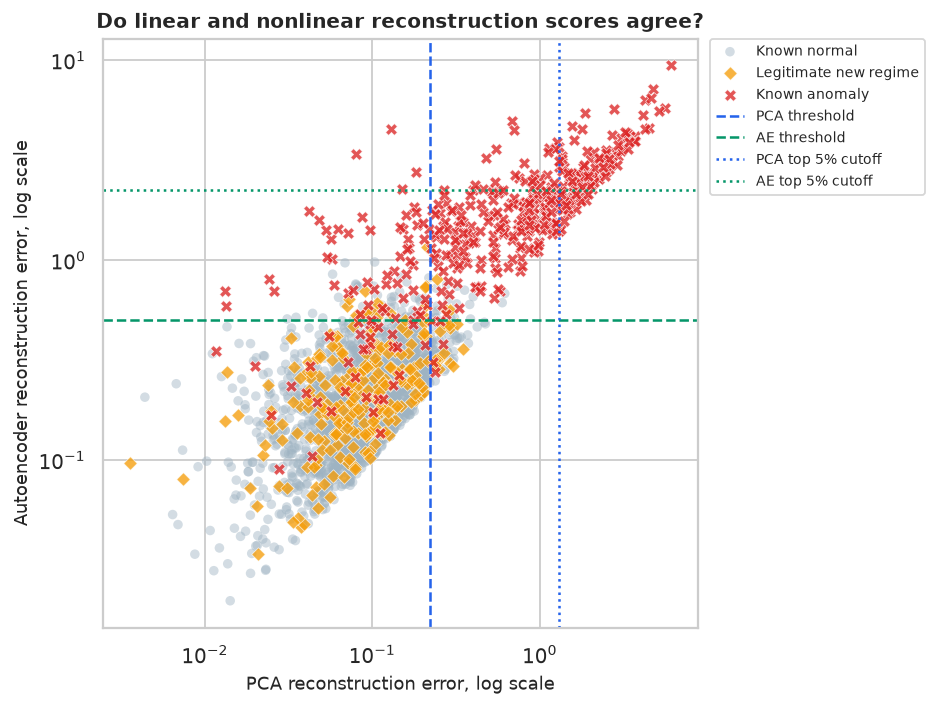

In [5]:
# Section focus: 8. Compare PCA and Autoencoder Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

review_fraction = 0.05
pca_review_cutoff = np.quantile(future_df['pca_score'], 1 - review_fraction)
ae_review_cutoff = np.quantile(future_df['ae_score'], 1 - review_fraction)
future_df['pca_review_alert'] = future_df['pca_score'] >= pca_review_cutoff
future_df['ae_review_alert'] = future_df['ae_score'] >= ae_review_cutoff

fig, ax = plt.subplots(figsize=(7.4, 5.6))
for status, color, marker in [
    ('Known normal', PALETTE['normal'], 'o'),
    ('Legitimate new regime', PALETTE['new_regime'], 'D'),
    ('Known anomaly', PALETTE['anomaly'], 'X'),
]:
    subset = future_df[future_df['status'] == status]
    ax.scatter(
        subset['pca_score'],
        subset['ae_score'],
        s=28 if status != 'Known anomaly' else 42,
        alpha=0.45 if status == 'Known normal' else 0.78,
        c=color,
        marker=marker,
        label=status,
        edgecolors='white' if status != 'Known normal' else 'none',
        linewidths=0.4,
    )
ax.axvline(pca_threshold, color=PALETTE['pca'], linestyle='--', linewidth=1.4, label='PCA threshold')
ax.axhline(ae_threshold, color=PALETTE['ae'], linestyle='--', linewidth=1.4, label='AE threshold')
ax.axvline(pca_review_cutoff, color=PALETTE['pca'], linestyle=':', linewidth=1.4, label='PCA top 5% cutoff')
ax.axhline(ae_review_cutoff, color=PALETTE['ae'], linestyle=':', linewidth=1.4, label='AE top 5% cutoff')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('PCA reconstruction error, log scale')
ax.set_ylabel('Autoencoder reconstruction error, log scale')
ax.set_title('Do linear and nonlinear reconstruction scores agree?')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()


The upper-right region contains cases that both models struggle to reconstruct. Those are high-confidence review candidates. Cases that are high on one score but not the other deserve closer inspection.

This plot also separates two deployment ideas:

- The dashed lines are validation-calibrated model boundaries.
- The dotted lines are review-capacity cutoffs.

A model boundary may flag too many cases for immediate investigation. A top queue may be operationally realistic but can miss lower-scoring failures.


## 9. Quantitative Evaluation Under Simulated Labels

In real anomaly detection projects, clean future labels are often incomplete. Here we use synthetic labels only to understand behavior.

We evaluate two alert rules for each model:

1. **Boundary alert:** score exceeds the 95th percentile of normal validation scores.
2. **Top-5% review:** score is in the top 5% of future observations.

The first rule is a statistical monitoring rule. The second rule is an analyst-capacity rule.


,model,rule,alert_rate,precision,recall,false_alert_rate_on_non_anomalies,average_precision,roc_auc
0,PCA residual,95th pct validation boundary,18.2%,74.7%,77.8%,5.6%,0.843,0.899
1,PCA residual,Top 5% review queue,5.0%,100.0%,28.8%,0.0%,0.843,0.899
2,Autoencoder residual,95th pct validation boundary,19.5%,80.8%,90.2%,4.5%,0.942,0.969
3,Autoencoder residual,Top 5% review queue,5.0%,100.0%,28.8%,0.0%,0.942,0.969


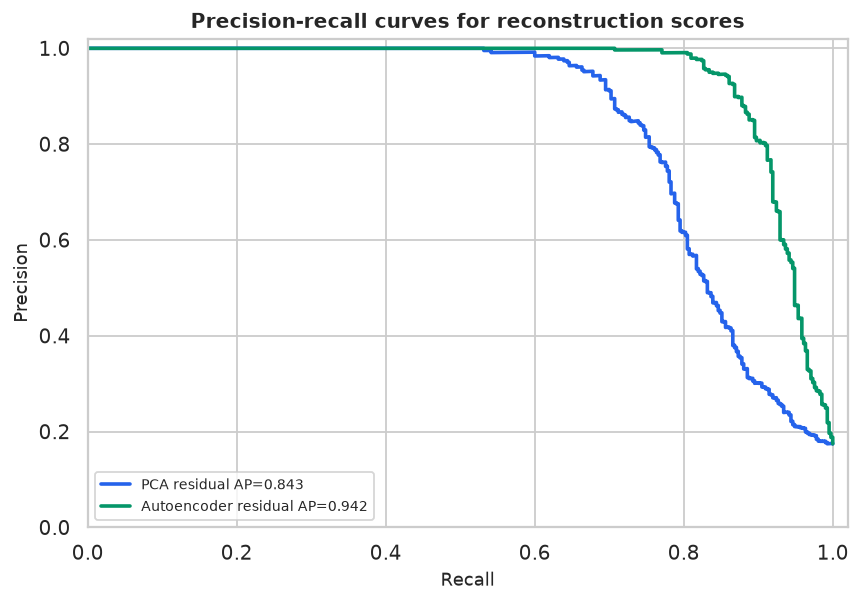

In [6]:
# Section focus: 9. Quantitative Evaluation Under Simulated Labels.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def alert_metrics(score_col, alert_col, model_name, rule_name):
    """Carry out the alert metrics step used in the 09. Reconstruction-Based Detection: PCA and Autoencoders workflow.
    
    Parameters
    ----------
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    alert_col : object
        Column name indicating whether an alert was fired by the detector.
    model_name : object
        Model object fitted, evaluated, or compared in this workflow.
    rule_name : object
        The rule name setting that controls the alert metrics calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    y = future_df['known_anomaly'].to_numpy().astype(int)
    score = future_df[score_col].to_numpy()
    alert = future_df[alert_col].to_numpy().astype(bool)
    tp = ((alert == 1) & (y == 1)).sum()
    fp = ((alert == 1) & (y == 0)).sum()
    fn = ((alert == 0) & (y == 1)).sum()
    tn = ((alert == 0) & (y == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    false_alert_rate = fp / (fp + tn) if (fp + tn) else np.nan
    return {
        'model': model_name,
        'rule': rule_name,
        'alert_rate': alert.mean(),
        'precision': precision,
        'recall': recall,
        'false_alert_rate_on_non_anomalies': false_alert_rate,
        'average_precision': average_precision_score(y, score),
        'roc_auc': roc_auc_score(y, score),
    }

metrics_table = pd.DataFrame([
    alert_metrics('pca_score', 'pca_boundary_alert', 'PCA residual', '95th pct validation boundary'),
    alert_metrics('pca_score', 'pca_review_alert', 'PCA residual', 'Top 5% review queue'),
    alert_metrics('ae_score', 'ae_boundary_alert', 'Autoencoder residual', '95th pct validation boundary'),
    alert_metrics('ae_score', 'ae_review_alert', 'Autoencoder residual', 'Top 5% review queue'),
])

smart_display(metrics_table.style.format({
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_alert_rate_on_non_anomalies': '{:.1%}',
    'average_precision': '{:.3f}',
    'roc_auc': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(6.8, 4.8))
y = future_df['known_anomaly'].to_numpy().astype(int)
for score_col, label, color in [
    ('pca_score', 'PCA residual', PALETTE['pca']),
    ('ae_score', 'Autoencoder residual', PALETTE['ae']),
]:
    precision, recall, _ = precision_recall_curve(y, future_df[score_col].to_numpy())
    ap = average_precision_score(y, future_df[score_col].to_numpy())
    ax.plot(recall, precision, linewidth=2.0, color=color, label=f'{label} AP={ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curves for reconstruction scores')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


Average precision and ROC AUC evaluate the ranking induced by the score. Precision, recall, and false-alert rate evaluate a concrete operational rule.

This distinction is central. A model can rank anomalies well but still create an unacceptable alert load under a validation threshold. Conversely, a fixed review queue can preserve analyst capacity but cap recall when anomalies are more common than the review budget.


## 10. Which Regimes Are Flagged?

Aggregate metrics can hide whether a detector is useful for the right kinds of risk. We now compare alert rates by regime.

This is where reconstruction detectors often reveal their operating personality. They may be excellent at obvious mechanical faults, less sensitive to subtle quality drift, and too sensitive to legitimate new regimes.


,regime,rows,known_anomaly,pca_boundary_alert_rate,ae_boundary_alert_rate,pca_review_rate,ae_review_rate,median_pca_score,median_ae_score
0,bearing_wear,95,1,98.9%,100.0%,69.5%,62.1%,1.9154,2.6440
1,control_loop_oscillation,75,1,94.7%,100.0%,13.3%,32.0%,0.7758,1.8223
2,new_product_grade,260,0,6.9%,7.7%,0.0%,0.0%,0.0898,0.2239
3,normal_peak_load,530,0,6.2%,4.3%,0.0%,0.0%,0.0917,0.2160
4,normal_steady,1150,0,5.0%,3.9%,0.0%,0.0%,0.0875,0.2025
5,recipe_mismatch,80,1,100.0%,100.0%,52.5%,36.2%,1.3062,2.0896
6,sensor_bias,80,1,75.0%,97.5%,0.0%,6.2%,0.3113,1.4043
7,stealth_quality_drift,80,1,17.5%,52.5%,0.0%,1.2%,0.1007,0.5236


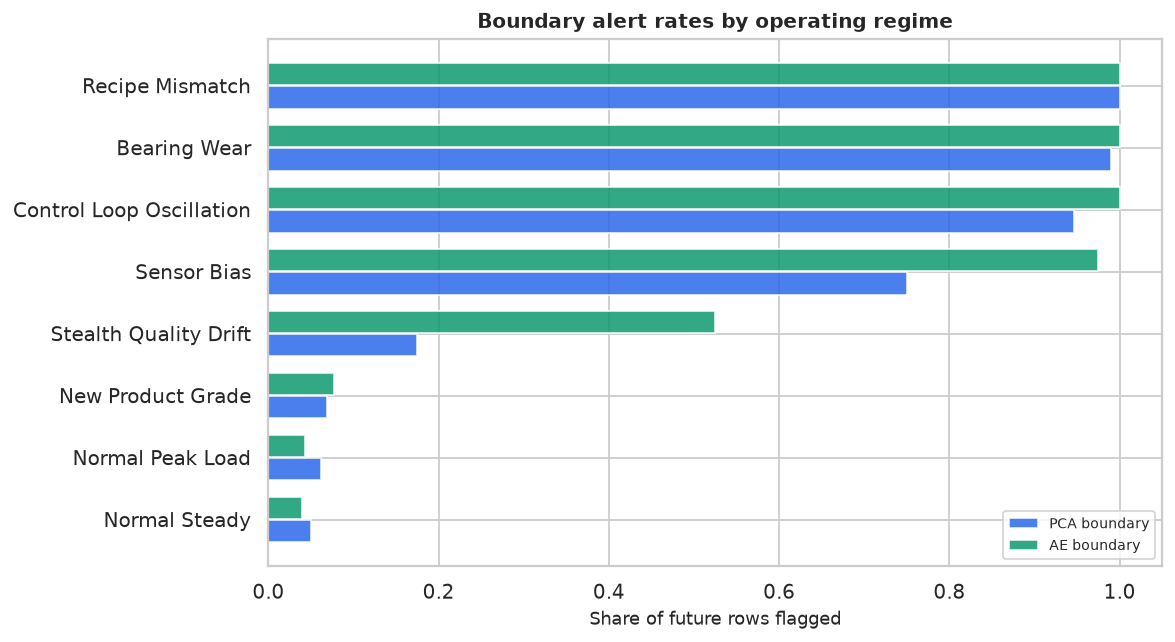

In [7]:
# Section focus: 10. Which Regimes Are Flagged?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

segment_table = future_df.groupby('regime').agg(
    rows=('regime', 'size'),
    known_anomaly=('known_anomaly', 'max'),
    pca_boundary_alert_rate=('pca_boundary_alert', 'mean'),
    ae_boundary_alert_rate=('ae_boundary_alert', 'mean'),
    pca_review_rate=('pca_review_alert', 'mean'),
    ae_review_rate=('ae_review_alert', 'mean'),
    median_pca_score=('pca_score', 'median'),
    median_ae_score=('ae_score', 'median'),
).reset_index()

smart_display(segment_table.style.format({
    'pca_boundary_alert_rate': '{:.1%}',
    'ae_boundary_alert_rate': '{:.1%}',
    'pca_review_rate': '{:.1%}',
    'ae_review_rate': '{:.1%}',
    'median_pca_score': '{:.4f}',
    'median_ae_score': '{:.4f}',
}))

plot_table = segment_table.sort_values('ae_boundary_alert_rate')
y_pos = np.arange(len(plot_table))
fig, ax = plt.subplots(figsize=(9.2, 5.1))
ax.barh(y_pos - 0.19, plot_table['pca_boundary_alert_rate'], height=0.36, color=PALETTE['pca'], alpha=0.82, label='PCA boundary')
ax.barh(y_pos + 0.19, plot_table['ae_boundary_alert_rate'], height=0.36, color=PALETTE['ae'], alpha=0.82, label='AE boundary')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_table['regime'].str.replace('_', ' ').str.title())
ax.set_xlabel('Share of future rows flagged')
ax.set_title('Boundary alert rates by operating regime')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


The segment table is usually more decision-relevant than a single global score. It shows whether the detector is catching the failures stakeholders care about and whether it is over-alerting legitimate business changes.

A high alert rate on the legitimate new product grade is not necessarily a defect. It may be a useful change-detection signal. But it should route to model validation or process-change review, not directly to the same fault queue as bearing wear or recipe mismatch.


## 11. Feature-Level Residuals for a Selected Alert

Reconstruction error can be decomposed by feature:

$$
e_j(x) = (x_j - \hat{x}_j)^2.
$$

This does not prove root cause. In correlated systems, an error in one sensor can produce residuals in several reconstructed variables. Still, feature residuals provide a useful starting point for analyst triage.


,selected_future_row,regime,known_anomaly,pca_score,ae_score,pca_review_alert,ae_review_alert
0,1206,bearing_wear,1,6.0808,9.4337,True,True


,feature,standardized_value,pca_reconstruction,pca_squared_residual,ae_reconstruction,ae_squared_residual,ae_share_of_total,pca_share_of_total
3,vibration_rms,16.22,9.00,52.235,6.46,95.254,84.1%,71.6%
8,energy_kwh,8.65,9.64,0.985,6.23,5.834,5.2%,1.3%
5,hydraulic_pressure,2.26,3.07,0.665,4.60,5.491,4.9%,0.9%
9,defect_proxy,6.53,7.40,0.765,4.74,3.199,2.8%,1.0%
4,bearing_temp_c,6.81,7.52,0.506,5.69,1.261,1.1%,0.7%
7,cycle_time_sec,2.62,5.25,6.923,3.59,0.947,0.8%,9.5%
11,sensor_noise_index,2.30,2.50,0.040,1.54,0.577,0.5%,0.1%
6,flow_rate,-0.78,0.50,1.648,-0.28,0.253,0.2%,2.3%


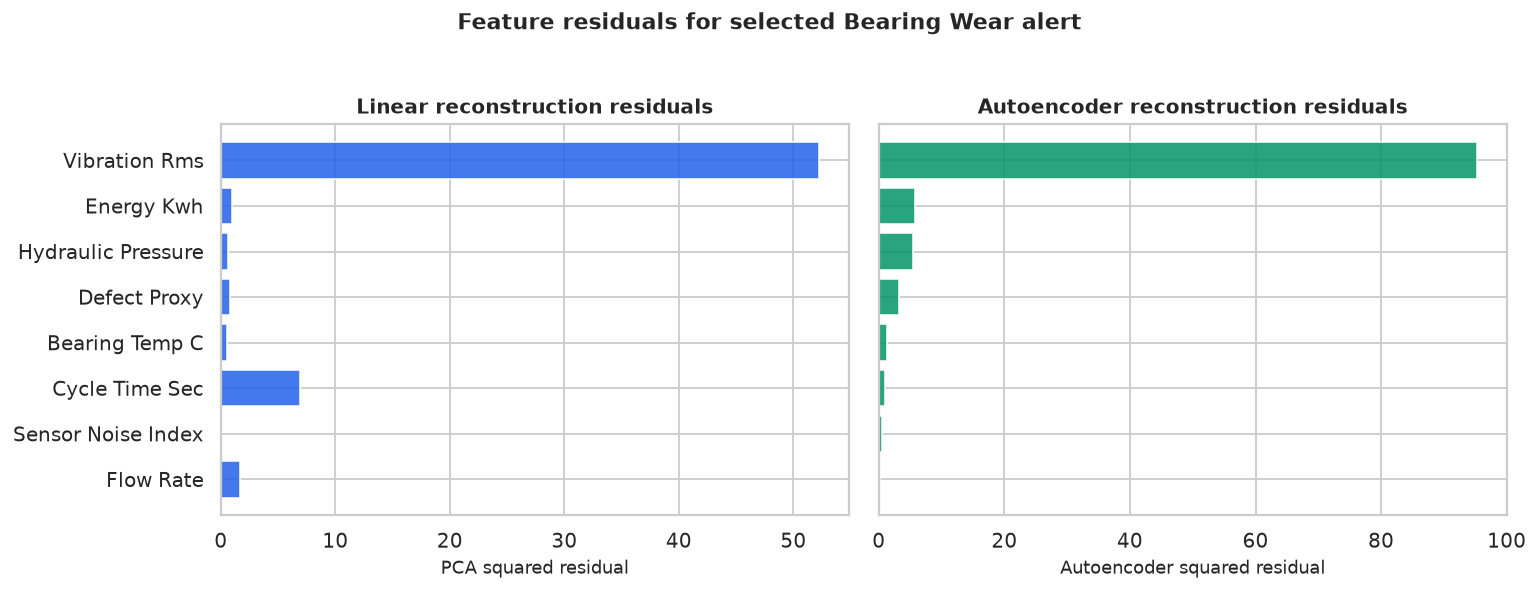

In [8]:
# Section focus: 11. Feature-Level Residuals for a Selected Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

X_future_pca_hat = pca_reconstruct(X_future)
X_future_ae_hat = autoencoder.predict(X_future)

candidate_mask = future_df['known_anomaly'].eq(1) & future_df['ae_review_alert']
selected_idx = future_df.loc[candidate_mask, 'ae_score'].idxmax()
selected_row = future_df.loc[selected_idx]

pca_residual = (X_future[selected_idx] - X_future_pca_hat[selected_idx]) ** 2
ae_residual = (X_future[selected_idx] - X_future_ae_hat[selected_idx]) ** 2
residual_table = pd.DataFrame({
    'feature': FEATURE_COLS,
    'standardized_value': X_future[selected_idx],
    'pca_reconstruction': X_future_pca_hat[selected_idx],
    'pca_squared_residual': pca_residual,
    'ae_reconstruction': X_future_ae_hat[selected_idx],
    'ae_squared_residual': ae_residual,
}).assign(
    ae_share_of_total=lambda d: d['ae_squared_residual'] / d['ae_squared_residual'].sum(),
    pca_share_of_total=lambda d: d['pca_squared_residual'] / d['pca_squared_residual'].sum(),
).sort_values('ae_squared_residual', ascending=False)

selected_summary = pd.DataFrame([
    {
        'selected_future_row': int(selected_idx),
        'regime': selected_row['regime'],
        'known_anomaly': int(selected_row['known_anomaly']),
        'pca_score': selected_row['pca_score'],
        'ae_score': selected_row['ae_score'],
        'pca_review_alert': bool(selected_row['pca_review_alert']),
        'ae_review_alert': bool(selected_row['ae_review_alert']),
    }
])
smart_display(selected_summary.style.format({'pca_score': '{:.4f}', 'ae_score': '{:.4f}'}))
smart_display(residual_table.head(8).style.format({
    'standardized_value': '{:.2f}',
    'pca_reconstruction': '{:.2f}',
    'pca_squared_residual': '{:.3f}',
    'ae_reconstruction': '{:.2f}',
    'ae_squared_residual': '{:.3f}',
    'ae_share_of_total': '{:.1%}',
    'pca_share_of_total': '{:.1%}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
plot_resid = residual_table.head(8).iloc[::-1]
axes[0].barh(plot_resid['feature'].str.replace('_', ' ').str.title(), plot_resid['pca_squared_residual'], color=PALETTE['pca'], alpha=0.86)
axes[0].set_xlabel('PCA squared residual')
axes[0].set_title('Linear reconstruction residuals')
axes[1].barh(plot_resid['feature'].str.replace('_', ' ').str.title(), plot_resid['ae_squared_residual'], color=PALETTE['ae'], alpha=0.86)
axes[1].set_xlabel('Autoencoder squared residual')
axes[1].set_title('Autoencoder reconstruction residuals')
plt.suptitle(f'Feature residuals for selected {selected_row["regime"].replace("_", " ").title()} alert', y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Feature residuals translate a black-box-looking score into a review starting point. The analyst can ask: which measured relationships failed to reconstruct?

But residual attribution must be handled carefully. In correlated telemetry, one physical fault can appear as residual error across multiple variables. Goldthorpe and Desmet (2018) emphasize that reconstruction error can spill over to correlated channels, so feature residuals should be treated as clues rather than definitive causes.


## 12. What Reconstruction Can Miss

The most important limitation is not false positives. It is false reassurance.

A dangerous case may have low reconstruction error if it lies on the learned normal manifold or if the model is flexible enough to reconstruct it. This can happen when the anomaly changes the business meaning of the observation without strongly violating the statistical relationships among sensors.

We inspect the lowest-scoring known anomalies to see which failure types are easiest for the reconstruction models to miss.


In [9]:
# Section focus: 12. What Reconstruction Can Miss.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

missed_candidates = future_df[future_df['known_anomaly'].eq(1)].copy()
missed_candidates['combined_rank_score'] = missed_candidates['pca_score'].rank(pct=True) + missed_candidates['ae_score'].rank(pct=True)
missed_table = missed_candidates.sort_values('combined_rank_score').head(8)[
    ['regime', 'pca_score', 'ae_score', 'pca_boundary_alert', 'ae_boundary_alert', 'pca_review_alert', 'ae_review_alert']
]
smart_display(missed_table.style.format({'pca_score': '{:.4f}', 'ae_score': '{:.4f}'}))

low_score_by_type = missed_candidates.groupby('regime').agg(
    rows=('regime', 'size'),
    pca_boundary_recall=('pca_boundary_alert', 'mean'),
    ae_boundary_recall=('ae_boundary_alert', 'mean'),
    pca_review_recall=('pca_review_alert', 'mean'),
    ae_review_recall=('ae_review_alert', 'mean'),
    median_pca_score=('pca_score', 'median'),
    median_ae_score=('ae_score', 'median'),
).reset_index().sort_values('ae_boundary_recall')

smart_display(low_score_by_type.style.format({
    'pca_boundary_recall': '{:.1%}',
    'ae_boundary_recall': '{:.1%}',
    'pca_review_recall': '{:.1%}',
    'ae_review_recall': '{:.1%}',
    'median_pca_score': '{:.4f}',
    'median_ae_score': '{:.4f}',
}))


,regime,pca_score,ae_score,pca_boundary_alert,ae_boundary_alert,pca_review_alert,ae_review_alert
471,stealth_quality_drift,0.0278,0.0905,False,False,False,False
1411,stealth_quality_drift,0.0249,0.1691,False,False,False,False
111,stealth_quality_drift,0.0437,0.1052,False,False,False,False
1117,stealth_quality_drift,0.0465,0.1958,False,False,False,False
1251,stealth_quality_drift,0.0404,0.2163,False,False,False,False
1997,stealth_quality_drift,0.0329,0.2344,False,False,False,False
1759,stealth_quality_drift,0.0201,0.2975,False,False,False,False
1896,stealth_quality_drift,0.0117,0.3508,False,False,False,False


,regime,rows,pca_boundary_recall,ae_boundary_recall,pca_review_recall,ae_review_recall,median_pca_score,median_ae_score
4,stealth_quality_drift,80,17.5%,52.5%,0.0%,1.2%,0.1007,0.5236
3,sensor_bias,80,75.0%,97.5%,0.0%,6.2%,0.3113,1.4043
1,control_loop_oscillation,75,94.7%,100.0%,13.3%,32.0%,0.7758,1.8223
0,bearing_wear,95,98.9%,100.0%,69.5%,62.1%,1.9154,2.6440
2,recipe_mismatch,80,100.0%,100.0%,52.5%,36.2%,1.3062,2.0896


Low-scoring anomalies are not modeling trivia. They are exactly where governance matters.

If a subtle quality drift is not strongly separated by reconstruction error, the organization may need additional signals: supervised quality labels, process-control charts, causal root-cause analysis, domain-specific thresholds, or a model that monitors outcomes rather than only sensor consistency.


## 13. Decision Memo

A reconstruction detector is ready for pilot deployment only if it answers four questions:

| Question | What to inspect |
|---|---|
| Does the score rank risky cases highly? | Average precision, precision-recall curve, review-queue precision |
| Is the alert load feasible? | Boundary alert rate and top-queue size |
| Are legitimate new regimes over-alerted? | Segment alert rates for known business changes |
| Are important anomalies missed? | Low-score anomaly review and failure-type recall |

For this synthetic line-monitoring case, a reasonable recommendation is to pilot reconstruction scores as a **triage layer**, not as an automated shutdown rule. The detector should route high-score cases to review, route legitimate new product-grade alerts to model validation, and retain separate domain rules for subtle quality drift.


In [10]:
# Section focus: 13. Decision Memo.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommendation_table = pd.DataFrame([
    {
        'decision_area': 'Primary use',
        'recommendation': 'Use reconstruction scores to prioritize maintenance and quality review, not to automatically stop the line.',
        'evidence_from_notebook': 'Both PCA and autoencoder scores identify high-residual regimes, but alert rates vary by segment.',
    },
    {
        'decision_area': 'Thresholding',
        'recommendation': 'Maintain both a validation-calibrated boundary and a top-review queue.',
        'evidence_from_notebook': 'Boundary rules answer statistical novelty; top queues preserve analyst capacity.',
    },
    {
        'decision_area': 'Change management',
        'recommendation': 'Route legitimate new product-grade alerts to model validation rather than fault response.',
        'evidence_from_notebook': 'New normal regimes can have elevated reconstruction error because they were absent from baseline training.',
    },
    {
        'decision_area': 'Model risk',
        'recommendation': 'Do not rely on reconstruction alone for subtle quality drift.',
        'evidence_from_notebook': 'Some anomaly types can remain relatively reconstructable and require additional outcome or domain signals.',
    },
    {
        'decision_area': 'Human review',
        'recommendation': 'Use feature residuals as triage clues, then validate against physical process knowledge.',
        'evidence_from_notebook': 'Residuals are useful but can spill across correlated channels.',
    },
])

smart_display(recommendation_table)


,decision_area,recommendation,evidence_from_notebook
0,Primary use,"Use reconstruction scores to prioritize maintenance and quality review, not to automatically stop the line.","Both PCA and autoencoder scores identify high-residual regimes, but alert rates vary by segment."
1,Thresholding,Maintain both a validation-calibrated boundary and a top-review queue.,Boundary rules answer statistical novelty; top queues preserve analyst capacity.
2,Change management,Route legitimate new product-grade alerts to model validation rather than fault response.,New normal regimes can have elevated reconstruction error because they were absent from baseline training.
3,Model risk,Do not rely on reconstruction alone for subtle quality drift.,Some anomaly types can remain relatively reconstructable and require additional outcome or domain signals.
4,Human review,"Use feature residuals as triage clues, then validate against physical process knowledge.",Residuals are useful but can spill across correlated channels.


Read Decision Memo with the reviewer in mind. A good result points reviewers toward a smaller, better queue.


## 14. Key Takeaways

1. Reconstruction-based detectors learn normal relationships, then score cases by reconstruction error.
2. PCA residuals provide a transparent linear baseline and connect to classical statistical process monitoring.
3. Autoencoders generalize reconstruction to nonlinear bottleneck representations.
4. Reconstruction error is not a direct fault label. It is a signal that the case is poorly represented by normal training data.
5. Validation thresholds and top-review queues solve different operational problems.
6. Legitimate new regimes can look anomalous if they were absent from the baseline.
7. Some anomalies are reconstructable. This is why reconstruction scores should be paired with domain checks, outcome monitoring, and governance.


## References

- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys*, 41(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)
- Cheng, Z., Wang, S., Zhang, P., Wang, S., Liu, X., & Zhu, E. (2021). Improved autoencoder for unsupervised anomaly detection. *International Journal of Intelligent Systems*, 36(12), 7103-7125. [https://doi.org/10.1002/int.22582](https://doi.org/10.1002/int.22582)
- De Ketelaere, B., Hubert, M., & Schmitt, E. (2015). Overview of PCA-Based Statistical Process-Monitoring Methods for Time-Dependent, High-Dimensional Data. *Journal of Quality Technology*, 47(4), 318-335. [https://doi.org/10.1080/00224065.2015.11918137](https://doi.org/10.1080/00224065.2015.11918137)
- De Ketelaere, B., Rato, T. J., Schmitt, E., & Hubert, M. (2016). Statistical process monitoring of time-dependent data. *Quality Engineering*, 28(1), 127-142. [https://doi.org/10.1080/08982112.2015.1100474](https://doi.org/10.1080/08982112.2015.1100474)
- Goldthorpe, P. J., & Desmet, A. (2018). Denoising autoencoder anomaly detection for correlated data. *PHM Society European Conference*, 4(1). [https://doi.org/10.36001/phme.2018.v4i1.372](https://doi.org/10.36001/phme.2018.v4i1.372)
- Huang, P., Shang, J., Xu, Y., Hu, Z., Zhang, K., Dai, J., & Yan, H. (2023). Anomaly detection in radiotherapy plans using deep autoencoder networks. *Frontiers in Oncology*, 13. [https://doi.org/10.3389/fonc.2023.1142947](https://doi.org/10.3389/fonc.2023.1142947)
- Qin, S. J. (2003). Statistical process monitoring: Basics and beyond. *Journal of Chemometrics*, 17(8-9), 480-502. [https://doi.org/10.1002/cem.800](https://doi.org/10.1002/cem.800)
- Zimmerer, D., Koehl, S., Petersen, J., Isensee, F., & Maier-Hein, K. (2018). Context-encoding variational autoencoder for unsupervised anomaly detection. *arXiv*. [https://doi.org/10.48550/arxiv.1812.05941](https://doi.org/10.48550/arxiv.1812.05941)
